<a href="https://colab.research.google.com/github/shaswath-29/EDA_LABORATORY_ASSIGNMENT/blob/Exp8_01.09.2026/PCAandt_SNEmethodfordigitrecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Part A: Data Understanding and Preprocessing**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

In [2]:
nist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = nist.data, nist.target.astype(int)

In [3]:
num_samples = X.shape[0]
print(f"Number of samples: {num_samples}")

Number of samples: 70000


In [5]:
num_classes = len(np.unique(y))
print(f"Number of classes: {num_classes}")

Number of classes: 10


In [7]:
image_height = int(np.sqrt(X.shape[1]))
image_width = image_height
print(f"Image dimensions: {image_height}x{image_width}")

Image dimensions: 28x28


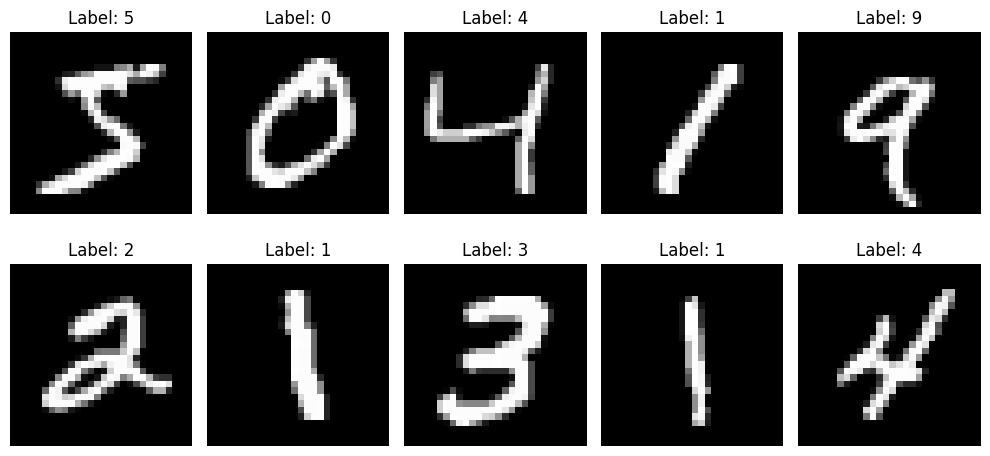

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X[i].reshape(image_height, image_width), cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [9]:
X_normalized = X / 255.0

In [10]:
print("Original min pixel value:", X.min())
print("Original max pixel value:", X.max())

Original min pixel value: 0
Original max pixel value: 255


In [11]:
print("Normalized min pixel value:", X_normalized.min())
print("Normalized max pixel value:", X_normalized.max())

Normalized min pixel value: 0.0
Normalized max pixel value: 1.0


In [12]:
print("Data shape after normalization:", X_normalized.shape)

Data shape after normalization: (70000, 784)


# **Part B: Principal Component Analysis (PCA)**

In [13]:
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(X_normalized)

In [14]:
explained_variance_ratio = pca.explained_variance_ratio_
print("Variance explained by each principal component (first 10 components):")
print(explained_variance_ratio[:10])

Variance explained by each principal component (first 10 components):
[0.09746116 0.07155445 0.06149531 0.05403385 0.04888934 0.04305227
 0.03278262 0.02889642 0.02758364 0.0234214 ]


In [15]:
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

In [16]:
components_90 = np.where(cumulative_variance_ratio >= 0.90)[0][0] + 1
print(f"Number of components to retain 90% variance: {components_90}")

Number of components to retain 90% variance: 87


In [17]:
components_95 = np.where(cumulative_variance_ratio >= 0.95)[0][0] + 1
print(f"Number of components to retain 95% variance: {components_95}")

Number of components to retain 95% variance: 154


In [18]:
components_99 = np.where(cumulative_variance_ratio >= 0.99)[0][0] + 1
print(f"Number of components to retain 99% variance: {components_99}")

Number of components to retain 99% variance: 331


In [19]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_normalized)
print(f"Shape of 2D PCA reduced data: {X_pca_2d.shape}")

Shape of 2D PCA reduced data: (70000, 2)


In [20]:
pca_50d = PCA(n_components=50)
X_pca_50d = pca_50d.fit_transform(X_normalized)
print(f"Shape of 50D PCA reduced data: {X_pca_50d.shape}")

Shape of 50D PCA reduced data: (70000, 50)


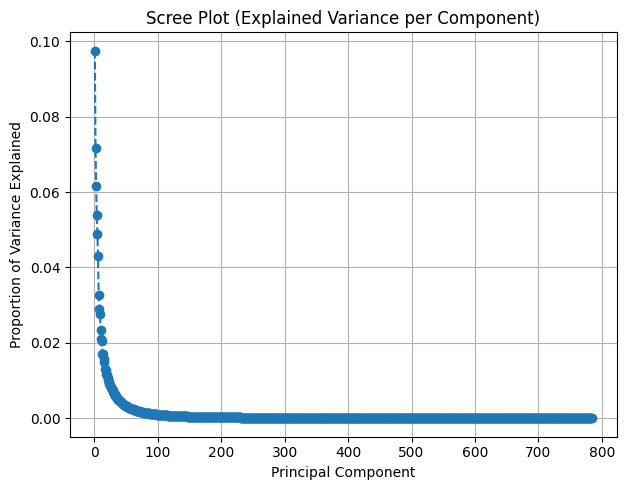

In [21]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.title('Scree Plot (Explained Variance per Component)')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.grid(True)
plt.tight_layout()
plt.show()

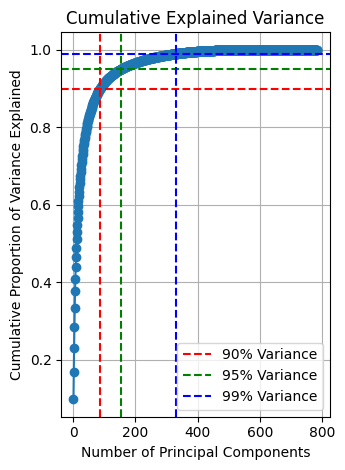

In [22]:
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Proportion of Variance Explained')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance')
plt.axvline(x=components_90, color='r', linestyle='--')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Variance')
plt.axvline(x=components_95, color='g', linestyle='--')
plt.axhline(y=0.99, color='b', linestyle='--', label='99% Variance')
plt.axvline(x=components_99, color='b', linestyle='--')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

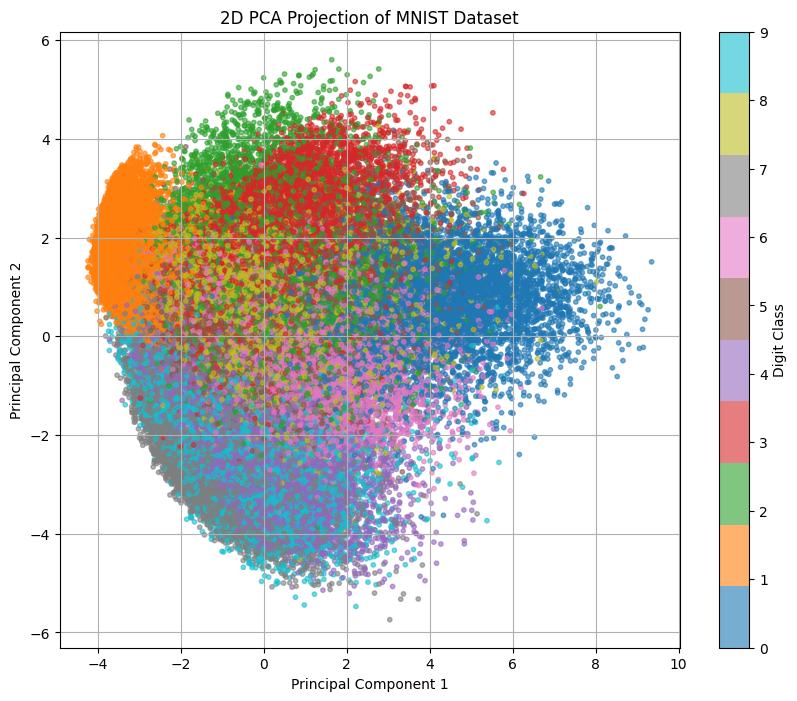

In [23]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter, ticks=range(10), label='Digit Class')
plt.title('2D PCA Projection of MNIST Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

# **Part C: t-SNE Visualization**

In [24]:
from sklearn.manifold import TSNE
import time
n_samples_tsne = 10000
np.random.seed(42)
idx = np.random.choice(X_normalized.shape[0], n_samples_tsne, replace=False)
X_tsne_sample = X_normalized[idx]
y_tsne_sample = y[idx]
X_pca_50d_tsne_sample = X_pca_50d[idx]


In [25]:
print("Applying t-SNE on original sampled data (perplexity=30):")
t0 = time.time()
tsne_original = TSNE(n_components=2, random_state=42, perplexity=30, n_jobs=-1, learning_rate='auto', init='pca')
X_tsne_original_2d = tsne_original.fit_transform(X_tsne_sample)
t1 = time.time()
print(f"t-SNE on original data took {t1 - t0:.2f} seconds")

Applying t-SNE on original sampled data (perplexity=30):
t-SNE on original data took 143.14 seconds


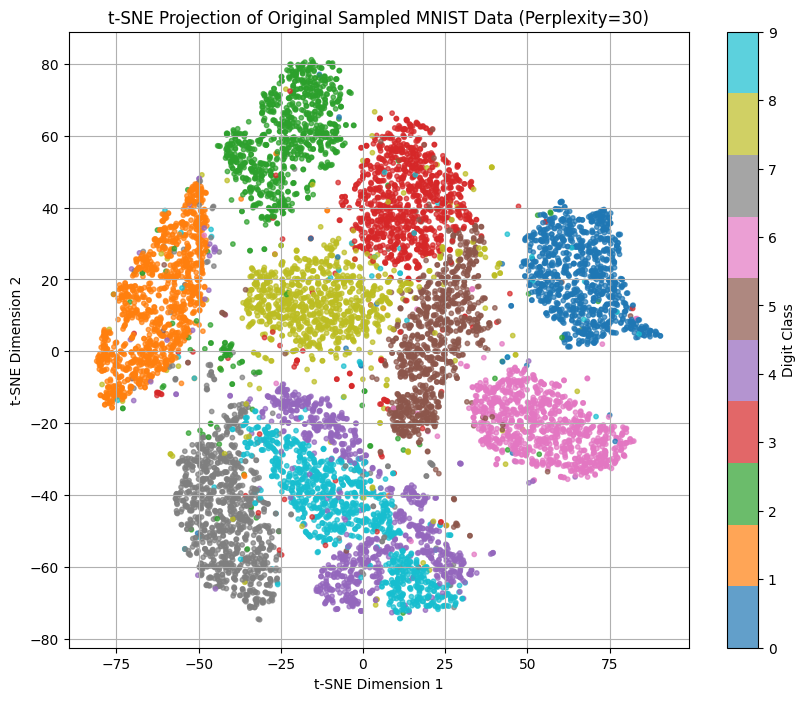

In [26]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne_original_2d[:, 0], X_tsne_original_2d[:, 1], c=y_tsne_sample, cmap='tab10', alpha=0.7, s=10)
plt.colorbar(scatter, ticks=range(10), label='Digit Class')
plt.title('t-SNE Projection of Original Sampled MNIST Data (Perplexity=30)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True)
plt.show()

In [27]:
print("Applying t-SNE on PCA-reduced (50D) sampled data (perplexity=30):")
t0 = time.time()
tsne_pca_reduced = TSNE(n_components=2, random_state=42, perplexity=30, n_jobs=-1, learning_rate='auto', init='pca')
X_tsne_pca_reduced_2d = tsne_pca_reduced.fit_transform(X_pca_50d_tsne_sample)
t1 = time.time()
print(f"t-SNE on PCA-reduced data took {t1 - t0:.2f} seconds")

Applying t-SNE on PCA-reduced (50D) sampled data (perplexity=30):
t-SNE on PCA-reduced data took 131.92 seconds


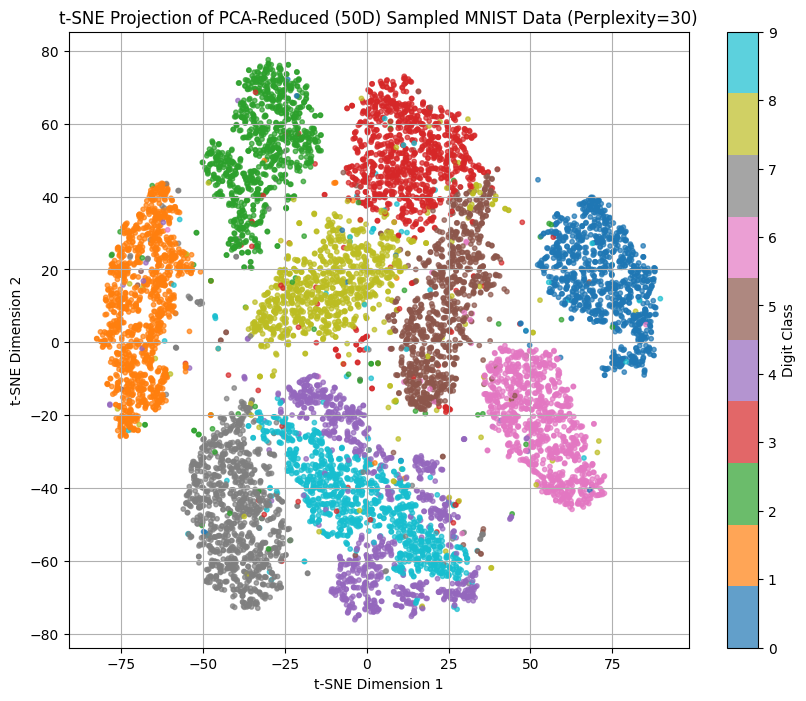

In [28]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne_pca_reduced_2d[:, 0], X_tsne_pca_reduced_2d[:, 1], c=y_tsne_sample, cmap='tab10', alpha=0.7, s=10)
plt.colorbar(scatter, ticks=range(10), label='Digit Class')
plt.title('t-SNE Projection of PCA-Reduced (50D) Sampled MNIST Data (Perplexity=30)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True)
plt.show()

In [29]:
perplexity_values = [5, 50]
for perplexity in perplexity_values:
    print(f"Applying t-SNE on PCA-reduced (50D) sampled data (perplexity={perplexity}):")
    t0 = time.time()
    tsne_exp = TSNE(n_components=2, random_state=42, perplexity=perplexity, n_jobs=-1, learning_rate='auto', init='pca')
    X_tsne_exp_2d = tsne_exp.fit_transform(X_pca_50d_tsne_sample)
    t1 = time.time()
    print(f"t-SNE with perplexity={perplexity} took {t1 - t0:.2f} seconds")

Applying t-SNE on PCA-reduced (50D) sampled data (perplexity=5):
t-SNE with perplexity=5 took 118.59 seconds
Applying t-SNE on PCA-reduced (50D) sampled data (perplexity=50):
t-SNE with perplexity=50 took 144.09 seconds


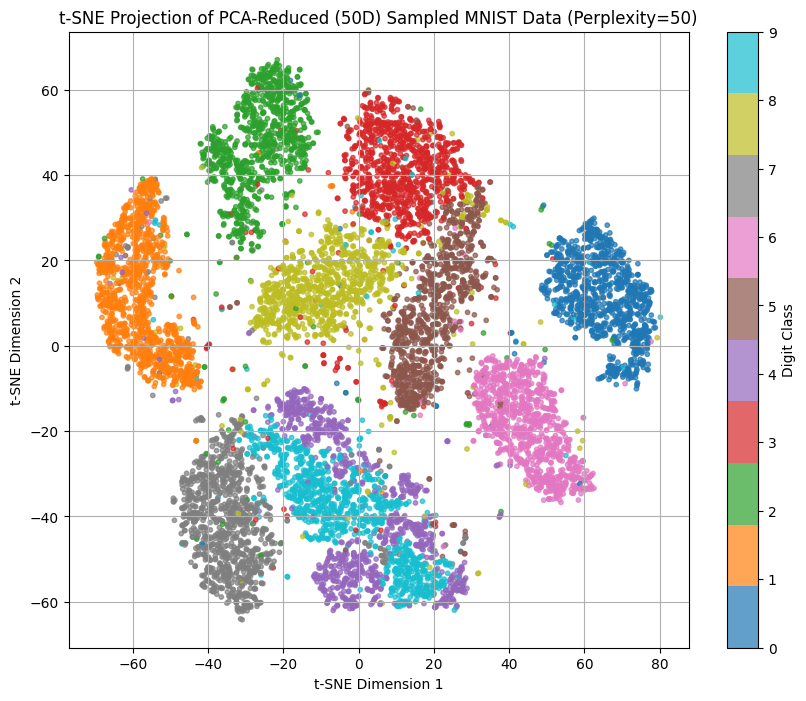

In [30]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne_exp_2d[:, 0], X_tsne_exp_2d[:, 1], c=y_tsne_sample, cmap='tab10', alpha=0.7, s=10)
plt.colorbar(scatter, ticks=range(10), label='Digit Class')
plt.title(f't-SNE Projection of PCA-Reduced (50D) Sampled MNIST Data (Perplexity={perplexity})')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True)
plt.show()

## **Part D: Digit Recognition Analysis**

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

In [33]:
pca_50d_train = PCA(n_components=50, random_state=42)
X_train_pca_50d = pca_50d_train.fit_transform(X_train)
X_test_pca_50d = pca_50d_train.transform(X_test)

In [34]:
print(f"Shape of original training data: {X_train.shape}")

Shape of original training data: (56000, 784)


In [35]:
print(f"Shape of PCA-transformed (50D) training data: {X_train_pca_50d.shape}")

Shape of PCA-transformed (50D) training data: (56000, 50)


In [36]:
print("Training KNN on original 784-dimensional data...")
knn_original = KNeighborsClassifier(n_neighbors=5)

t0 = time.time()
knn_original.fit(X_train, y_train)
train_time_original = time.time() - t0
print(f"Training time (Original data): {train_time_original:.2f} seconds")

Training KNN on original 784-dimensional data...
Training time (Original data): 0.11 seconds


In [37]:
t0 = time.time()
y_pred_original = knn_original.predict(X_test)
predict_time_original = time.time() - t0
print(f"Prediction time (Original data): {predict_time_original:.2f} seconds")

Prediction time (Original data): 56.58 seconds


In [38]:
accuracy_original = accuracy_score(y_test, y_pred_original)
print(f"Classification Accuracy (Original data): {accuracy_original:.4f}")


Classification Accuracy (Original data): 0.9701


In [39]:
print("Training KNN on PCA-transformed (50-dimensional) data...")
knn_pca = KNeighborsClassifier(n_neighbors=5)

t0 = time.time()
knn_pca.fit(X_train_pca_50d, y_train)
train_time_pca = time.time() - t0
print(f"Training time (PCA data): {train_time_pca:.2f} seconds")

Training KNN on PCA-transformed (50-dimensional) data...
Training time (PCA data): 0.02 seconds


In [40]:
t0 = time.time()
y_pred_pca = knn_pca.predict(X_test_pca_50d)
predict_time_pca = time.time() - t0
print(f"Prediction time (PCA data): {predict_time_pca:.2f} seconds")

Prediction time (PCA data): 10.01 seconds


In [41]:
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print(f"Classification Accuracy (PCA data): {accuracy_pca:.4f}")

Classification Accuracy (PCA data): 0.9739
